# Exploration: Time Stamps

Parsing the timestamps and understanding them

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path
from anomaly_detection.etl.load import load_timestamps, load_timestamps_df, load_records

plt.style.use('ggplot')

In [7]:
# Path to the data
project_folder = Path.cwd().parent

evtx_path = project_folder / "data/raw/93_applog.evtx"

evtx_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/raw/93_applog.evtx')

In [3]:
output_path = project_folder / "data/time_exploration/application"

output_path

WindowsPath('c:/Users/hp/Documents/School/anomaly-detection/data/time_exploration/application')

In [4]:
timestamps = load_timestamps(evtx_path)

len(timestamps)

21102

In [5]:
timestamps_df = load_timestamps_df(evtx_path)

timestamps_df.head(10)

,timestamp,minute,minute_of_hour,hour,hour_of_day,deltatime
0,2026-06-12 10:56:03.411997900+00:00,2026-06-12 10:56:00+00:00,56,2026-06-12 10:00:00+00:00,10,0 days 00:00:20.289853383
1,2026-06-12 10:56:03.474792600+00:00,2026-06-12 10:56:00+00:00,56,2026-06-12 10:00:00+00:00,10,0 days 00:00:00.062794700
2,2026-06-12 10:56:03.474792600+00:00,2026-06-12 10:56:00+00:00,56,2026-06-12 10:00:00+00:00,10,0 days 00:00:00
3,2026-06-12 10:56:03.490418+00:00,2026-06-12 10:56:00+00:00,56,2026-06-12 10:00:00+00:00,10,0 days 00:00:00.015625400
4,2026-06-12 10:58:00.748940800+00:00,2026-06-12 10:58:00+00:00,58,2026-06-12 10:00:00+00:00,10,0 days 00:01:57.258522800
5,2026-06-12 10:58:03.033235300+00:00,2026-06-12 10:58:00+00:00,58,2026-06-12 10:00:00+00:00,10,0 days 00:00:02.284294500
6,2026-06-12 10:58:03.033235300+00:00,2026-06-12 10:58:00+00:00,58,2026-06-12 10:00:00+00:00,10,0 days 00:00:00
7,2026-06-12 10:58:03.048862900+00:00,2026-06-12 10:58:00+00:00,58,2026-06-12 10:00:00+00:00,10,0 days 00:00:00.015627600
8,2026-06-12 10:58:03.064486500+00:00,2026-06-12 10:58:00+00:00,58,2026-06-12 10:00:00+00:00,10,0 days 00:00:00.015623600
9,2026-06-12 11:00:01.311588600+00:00,2026-06-12 11:00:00+00:00,0,2026-06-12 11:00:00+00:00,11,0 days 00:01:58.247102100


In [6]:
# Export timestamps_df to csv and describe it
timestamps_df.to_csv(project_folder / "data/processed/timestamps.csv", index=False)

timestamps_df.describe(include='all')

,timestamp,minute,minute_of_hour,hour,hour_of_day,deltatime
count,21101,21101,21101.000000,21101,21101.000000,21101
mean,2026-06-14 22:47:57.028343040+00:00,2026-06-14 22:47:52.931140608+00:00,28.256576,2026-06-14 22:19:37.536609792+00:00,11.511682,0 days 00:00:20.289853383
min,2026-06-12 10:56:03.411997900+00:00,2026-06-12 10:56:00+00:00,0.000000,2026-06-12 10:00:00+00:00,0.000000,0 days 00:00:00
25%,2026-06-13 17:12:26.181270016+00:00,2026-06-13 17:12:00+00:00,14.000000,2026-06-13 17:00:00+00:00,6.000000,0 days 00:00:00
50%,2026-06-14 23:24:00.758247168+00:00,2026-06-14 23:24:00+00:00,28.000000,2026-06-14 23:00:00+00:00,12.000000,0 days 00:00:00.062498400
75%,2026-06-16 04:14:02.838862592+00:00,2026-06-16 04:14:00+00:00,44.000000,2026-06-16 04:00:00+00:00,18.000000,0 days 00:00:06.281155600
max,2026-06-17 09:51:19.318394+00:00,2026-06-17 09:51:00+00:00,59.000000,2026-06-17 09:00:00+00:00,23.000000,0 days 00:02:00.818966600
std,NaN,NaN,17.427218,NaN,6.930243,0 days 00:00:38.762646936


In [7]:
# Count events per minute and events per hour for plotting
events_per_minute = (
    timestamps_df
    .groupby("minute")
    .size()
    .rename("events")
    .reset_index()
)

events_per_hour = (
    timestamps_df
    .groupby("hour")
    .size()
    .rename("events")
    .reset_index()
)

events_per_hour

,hour,events
0,2026-06-12 10:00:00+00:00,9
1,2026-06-12 11:00:00+00:00,172
2,2026-06-12 12:00:00+00:00,170
3,2026-06-12 13:00:00+00:00,170
4,2026-06-12 14:00:00+00:00,176
...,...,...
115,2026-06-17 05:00:00+00:00,177
116,2026-06-17 06:00:00+00:00,183
117,2026-06-17 07:00:00+00:00,173
118,2026-06-17 08:00:00+00:00,175


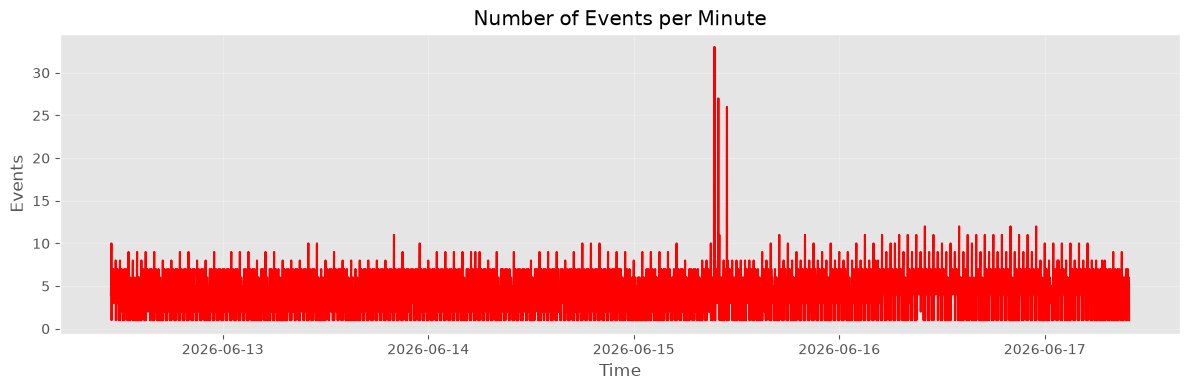

In [8]:
plt.figure(figsize=(12, 4))

plt.plot(
    events_per_minute["minute"],
    events_per_minute["events"],
    color="red"
)

plt.title("Number of Events per Minute")
plt.xlabel("Time")
plt.ylabel("Events")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(output_path / "events_per_minute.png")

plt.show()

In [9]:
events_by_minute_of_hour = (
    timestamps_df
    .groupby("minute_of_hour")
    .size()
    .reindex(range(60), fill_value=0)
    .rename("events")
    .reset_index()
)

events_by_hour_of_day = (
    timestamps_df
    .groupby("hour_of_day")
    .size()
    .reindex(range(24), fill_value=0)
    .rename("events")
    .reset_index()
)

events_by_hour_of_day

,hour_of_day,events
0,0,869
1,1,879
2,2,879
3,3,887
4,4,875
5,5,882
6,6,897
7,7,867
8,8,873
9,9,990


In [10]:
events_by_minute_of_hour_dict = events_by_minute_of_hour.to_dict(orient='records')

events_by_minute_of_hour_dict = [{str(record['minute_of_hour']).zfill(2): record['events']} for record in events_by_minute_of_hour_dict]

with open(output_path / "events_per_minutes_of_hour.txt", "w", encoding="utf-8") as file:
    file.write(json.dumps(
        events_by_minute_of_hour_dict,
        indent=4
    ))

events_by_minute_of_hour_dict

[{'00': 1102},
 {'01': 119},
 {'02': 597},
 {'03': 0},
 {'04': 598},
 {'05': 9},
 {'06': 716},
 {'07': 0},
 {'08': 596},
 {'09': 2},
 {'10': 679},
 {'11': 4},
 {'12': 810},
 {'13': 21},
 {'14': 597},
 {'15': 309},
 {'16': 595},
 {'17': 11},
 {'18': 597},
 {'19': 1},
 {'20': 607},
 {'21': 100},
 {'22': 597},
 {'23': 34},
 {'24': 611},
 {'25': 86},
 {'26': 603},
 {'27': 54},
 {'28': 630},
 {'29': 9},
 {'30': 900},
 {'31': 123},
 {'32': 597},
 {'33': 2},
 {'34': 596},
 {'35': 12},
 {'36': 700},
 {'37': 1},
 {'38': 597},
 {'39': 3},
 {'40': 677},
 {'41': 2},
 {'42': 807},
 {'43': 24},
 {'44': 596},
 {'45': 304},
 {'46': 595},
 {'47': 0},
 {'48': 597},
 {'49': 1},
 {'50': 606},
 {'51': 127},
 {'52': 611},
 {'53': 56},
 {'54': 595},
 {'55': 83},
 {'56': 595},
 {'57': 0},
 {'58': 595},
 {'59': 5}]

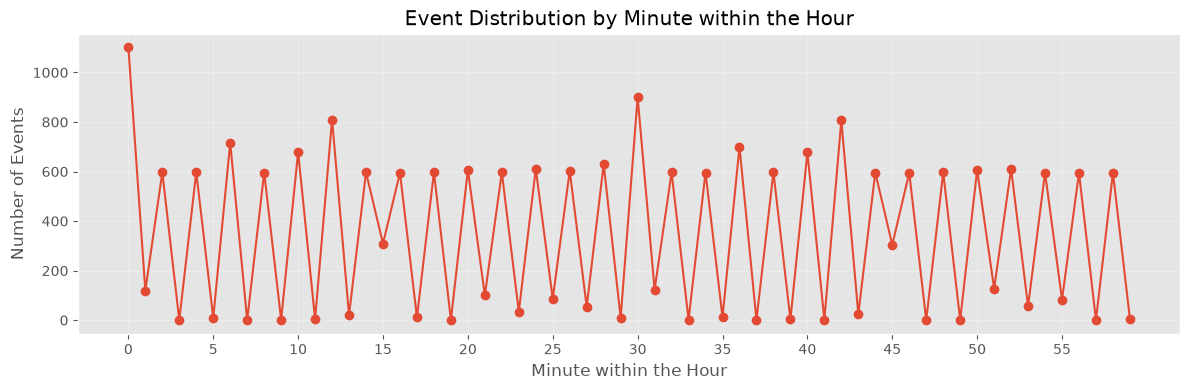

In [11]:
plt.figure(figsize=(12, 4))

plt.plot(
    events_by_minute_of_hour["minute_of_hour"],
    events_by_minute_of_hour["events"],
    marker="o"
)

plt.xticks(range(0, 60, 5))
plt.xlabel("Minute within the Hour")
plt.ylabel("Number of Events")
plt.title("Event Distribution by Minute within the Hour")

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(output_path / "events_per_minute_of_hour.png")

plt.show()

In [12]:
largest_deltatimes_df = timestamps_df.nlargest(
    20,
    "deltatime"
)[["timestamp", "deltatime"]]

largest_deltatimes_df

,timestamp,deltatime
21009,2026-06-17 09:20:04.605049500+00:00,0 days 00:02:00.818966600
5812,2026-06-13 20:18:03.241352600+00:00,0 days 00:02:00.541978600
12739,2026-06-15 10:58:02.967462600+00:00,0 days 00:02:00.005339200
12213,2026-06-15 08:58:03.044617+00:00,0 days 00:01:59.815284600
12761,2026-06-15 11:04:02.099118400+00:00,0 days 00:01:59.244328100
12862,2026-06-15 11:38:01.920585100+00:00,0 days 00:01:59.069820100
11945,2026-06-15 07:24:02.048136300+00:00,0 days 00:01:59.036903600
5233,2026-06-13 17:00:01.271407700+00:00,0 days 00:01:58.678777500
11647,2026-06-15 05:42:00.744562700+00:00,0 days 00:01:58.644554500
15722,2026-06-16 03:42:00.762798200+00:00,0 days 00:01:58.641636


In [13]:
largest_deltatimes_df.iloc[0, :]

i = int(largest_deltatimes_df.iloc[0, :].name) # type: ignore

burst_example_df = timestamps_df.loc[i-5:i+5, ["timestamp", "deltatime"]]

burst_example_df.to_csv(output_path / "burst_example.csv")

burst_example_df

,timestamp,deltatime
21004,2026-06-17 09:18:00.768586800+00:00,0 days 00:01:57.039022900
21005,2026-06-17 09:18:03.786082900+00:00,0 days 00:00:03.017496100
21006,2026-06-17 09:18:03.786082900+00:00,0 days 00:00:00
21007,2026-06-17 09:18:03.786082900+00:00,0 days 00:00:00
21008,2026-06-17 09:18:03.786082900+00:00,0 days 00:00:00
21009,2026-06-17 09:20:04.605049500+00:00,0 days 00:02:00.818966600
21010,2026-06-17 09:20:07.138473900+00:00,0 days 00:00:02.533424400
21011,2026-06-17 09:20:08.577961100+00:00,0 days 00:00:01.439487200
21012,2026-06-17 09:20:08.609209800+00:00,0 days 00:00:00.031248700
21013,2026-06-17 09:20:08.640459400+00:00,0 days 00:00:00.031249600
